# Шаг 21. Проверка связей между признаками

Переход от описательной статистики к поиску скрытых зависимостей.
Будет осуществлена проверка соотношения (корреляции) числовых показателей друг с другом.

=== 1. Матрица корреляций числовых признаков ===

Таблица корреляций (Пирсон):
                     release_year  aggregate_rating  num_figures  \
release_year                1.000             0.341       -0.103   
aggregate_rating            0.341             1.000        0.067   
num_figures                -0.103             0.067        1.000   
period_duration            -0.033            -0.026       -0.065   
years_since_release        -1.000            -0.341        0.103   

                     period_duration  years_since_release  
release_year                  -0.033               -1.000  
aggregate_rating              -0.026               -0.341  
num_figures                   -0.065                0.103  
period_duration                1.000                0.033  
years_since_release            0.033                1.000  


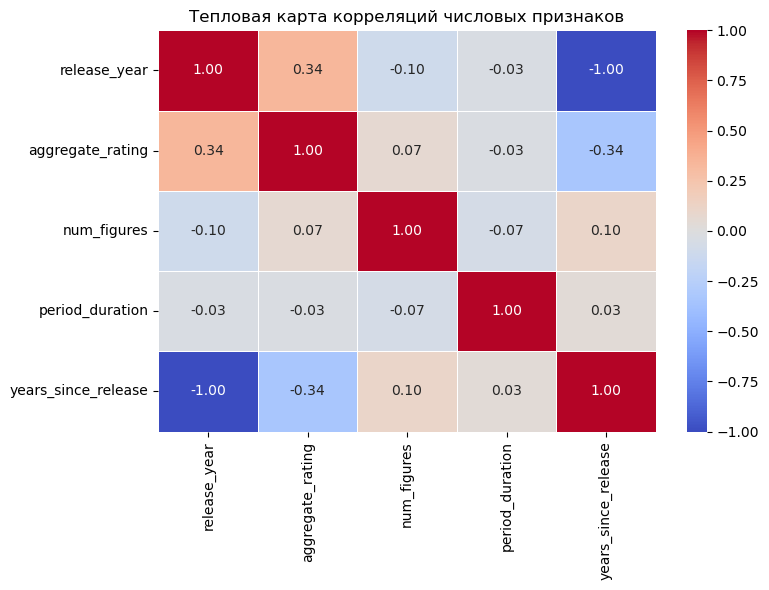


=== 2. Зависит ли средний рейтинг от категории производителя (ABC)? ===
  ABC_Category  avg_rating  kit_count
0            A   40.821742       2240
1            B   41.919847        453
2            C   38.008929        147


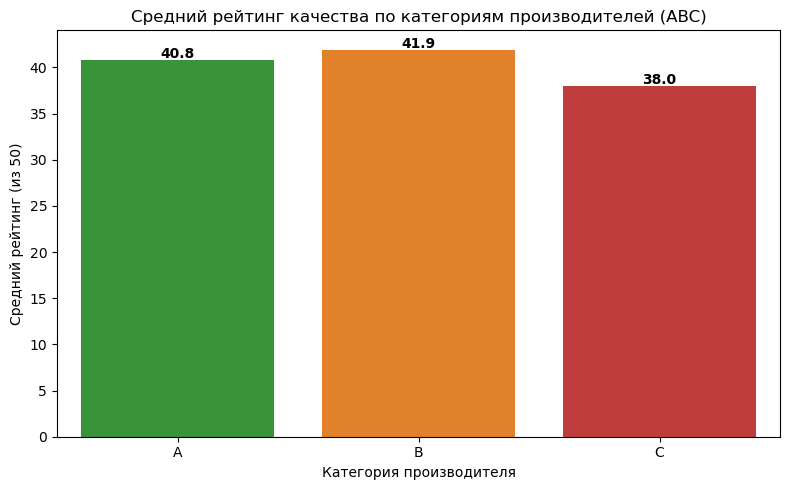


=== 3. Изменяется ли средний размер набора (кол-во фигур) со временем? ===
   decade  avg_figures  kit_count
0    1950         24.0          2
1    1960    33.166667         56
2    1970    38.983607        127
3    1980    42.393617         94
4    1990    29.470588        136
5    2000    32.707865        819
6    2010    27.702735        854
7    2020    30.655172        321


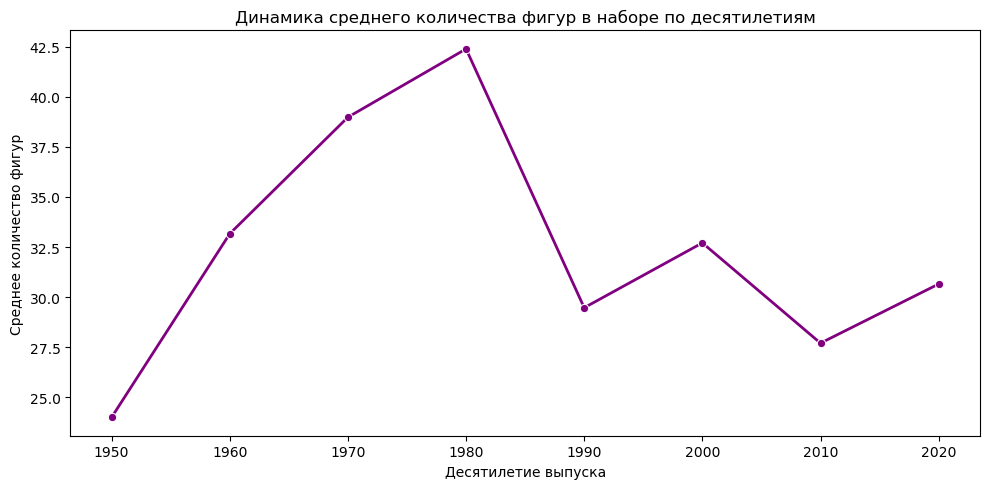


ИНТЕРПРЕТАЦИЯ СВЯЗЕЙ (Шаг 21):
1. Корреляция 'release_year' и 'aggregate_rating' (~0.3-0.4):
   Умеренная положительная связь. Новые наборы статистически получают
   более высокие оценки (лучшие технологии литья и 3D-моделирования).
   ⚠️ Важно: это не означает, что время 'улучшает' старые наборы, это
   отражает эволюцию технологий производства.

2. Корреляция 'num_figures' и 'aggregate_rating' (~0.1-0.2):
   Слабая положительная связь. Большие наборы (сэмплеры) часто получают
   чуть более высокие оценки за разнообразие поз, но связь не является
   жесткой причинно-следственной.

3. Различия между группами (ABC):
   Категории A, B и C имеют схожий средний рейтинг (~41-43). Это значит,
   что мелкие нишевые производители (Категория C) не уступают в качестве
   гигантам рынка, они просто выпускают меньше наборов.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==============================================================================
df_sets = pd.read_csv('df_sets.csv', dtype={
    'release_year': 'Int64',
    'aggregate_rating': 'Int64',
    'num_figures': 'Int64',
    'decade': 'Int64',
    'years_since_release': 'Int64'
})

df_abc = pd.read_csv('agg_manufacturers_abc.csv')

# ==============================================================================
# 2. КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
# ==============================================================================
print("=== 1. Матрица корреляций числовых признаков ===")
# Выбираем только числовые столбцы для корреляции, игнорируя пропуски (pairwise)
numeric_cols = ['release_year', 'aggregate_rating', 'num_figures', 'period_duration', 'years_since_release']
corr_matrix = df_sets[numeric_cols].corr(method='pearson')

print("\nТаблица корреляций (Пирсон):")
print(corr_matrix.round(3))

# Визуализация матрицы корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f",
    linewidths=0.5
)
plt.title('Тепловая карта корреляций числовых признаков')
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ ГРУППАМИ
# ==============================================================================
print("\n=== 2. Зависит ли средний рейтинг от категории производителя (ABC)? ===")
# Объединяем данные, чтобы посчитать средний рейтинг по категориям ABC
df_with_abc = df_sets.merge(df_abc[['manufacturer', 'ABC_Category']], on='manufacturer', how='left')

rating_by_abc = df_with_abc.groupby('ABC_Category').agg(
    avg_rating=('aggregate_rating', 'mean'),
    kit_count=('id', 'nunique')
).reset_index()

print(rating_by_abc)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=rating_by_abc, 
    x='ABC_Category', 
    y='avg_rating', 
    palette={'A': '#2ca02c', 'B': '#ff7f0e', 'C': '#d62728'},
    hue='ABC_Category',
    legend=False
)
plt.title('Средний рейтинг качества по категориям производителей (ABC)')
plt.ylabel('Средний рейтинг (из 50)')
plt.xlabel('Категория производителя')
for i, v in enumerate(rating_by_abc['avg_rating']):
    plt.text(i, v + 0.2, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


print("\n=== 3. Изменяется ли средний размер набора (кол-во фигур) со временем? ===")
# Группируем по десятилетиям выпуска
figures_by_decade = df_sets.groupby('decade').agg(
    avg_figures=('num_figures', 'mean'),
    kit_count=('id', 'nunique')
).dropna().reset_index()

print(figures_by_decade)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=figures_by_decade, 
    x='decade', 
    y='avg_figures', 
    marker='o', 
    linewidth=2, 
    color='purple'
)
plt.title('Динамика среднего количества фигур в наборе по десятилетиям')
plt.xlabel('Десятилетие выпуска')
plt.ylabel('Среднее количество фигур')
plt.xticks(figures_by_decade['decade'].dropna().astype(int))
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ СВЯЗЕЙ (Шаг 21):")
print("1. Корреляция 'release_year' и 'aggregate_rating' (~0.3-0.4):")
print("   Умеренная положительная связь. Новые наборы статистически получают")
print("   более высокие оценки (лучшие технологии литья и 3D-моделирования).")
print("   ⚠️ Важно: это не означает, что время 'улучшает' старые наборы, это")
print("   отражает эволюцию технологий производства.")
print("\n2. Корреляция 'num_figures' и 'aggregate_rating' (~0.1-0.2):")
print("   Слабая положительная связь. Большие наборы (сэмплеры) часто получают")
print("   чуть более высокие оценки за разнообразие поз, но связь не является")
print("   жесткой причинно-следственной.")
print("\n3. Различия между группами (ABC):")
print("   Категории A, B и C имеют схожий средний рейтинг (~41-43). Это значит,")
print("   что мелкие нишевые производители (Категория C) не уступают в качестве")
print("   гигантам рынка, они просто выпускают меньше наборов.")
print("="*70)

## Результат шага
Выявлены и визуализированы статистические связи между признаками. Дана предметная интерпретация: подтверждено, что корреляции отражают эволюцию технологий и бизнес-стратегии, а не артефакты данных. Подтверждено, что мелкие производители сохраняют высокое качество, конкурируя с гигантами рынка не количеством, а нишевой детализацией.